# Proyecto final del curso Introducción a los Procesos Gaussianos 2025 I
# Presentado por: Leonardo López
# Docente: Julian Gil, PhD

El objetivo de este proyecto es clasificar series de tiempo correspondientes a señales EEG de personas con TDAH y sujetos control, utilizando un enfoque bayesiano no paramétrico: Procesos Gaussianos para clasificación. Para ello, se representan las señales EEG sintéticas mediante Modelos Ocultos de Markov (HMM), capturando la dinámica de los estados latentes que describen los patrones temporales relevantes.

Se parte de un archivo CSV (hmm_final.csv) que contiene parámetros derivados de EEG mediante modelado HMM y etiquetas de clase (label: 0 para Control, 1 para TDAH). La estructura se optimiza automáticamente con optuna.




#### 1. Dataset

Sea el conjunto de entrenamiento:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N
$$

donde:

- $ x_i \in \mathbb{R}^d $: vector de características (parámetros HMM).
- $ y_i \in \{0, 1\}$: etiqueta (0 = Control, 1 = TDAH).

---

#### 2. Función latente

Se modela una función latente $ f(x) $ con un proceso gaussiano:

$$
f(x) \sim \mathcal{GP}(0, k(x, x'))
$$

donde $k(x,x')$ es el kernel que define la covarianza entre puntos.

---

#### 3. Likelihood para clasificación

Como el problema es de clasificación binaria, usamos una función sigmoide sobre $f(x)$ pR convertirlo en una probabilidad:

- Función logística:

$$
p(y = 1 \mid x) = \sigma(f(x)) = \frac{1}{1 + e^{-f(x)}}
$$

- Alternativamente, se puede utilizar la función probit:

$$
p(y = 1 \mid x) = \Phi(f(x))
$$

dado que *skalearn* usa por defecto una aproximación logística y Laplace para GPs para clasificación.

---

#### 4. Inferencia bayesiana (aproximada)

Como el likelihood no es gaussiano, no se puede obtener un posterior exacto, usamos aproximación (Laplace o EP). Para un nuevo punto $ x_* $, se predice:

$$
p(f_* \mid X,y, x_*) \approx \mathcal{N}(\mu_*, \sigma_*^2)
$$

Y la probabilidad estimada es:

$$
p(y_* = 1 \mid x_*) = \sigma(\mu_*)
$$

---

#### 5. Kernels utilizados

**RBF (Radial Basis Function)**:

$$
k_{\text{RBF}}(x, x') = \sigma^2 \exp\left(-\frac{ \|x - x'\|^2 }{2\ell^2} \right)
$$

**Matérn con $ \nu = 1.5 $**:

$$
k_{1.5}(x, x') = \sigma^2 \left(1 + \frac{ \sqrt{3} \|x - x'\| }{\ell} \right) \exp\left(-\frac{ \sqrt{3} \|x - x'\| }{\ell} \right)
$$

**Matérn con $ \nu = 2.5 $**:

$$
k_{2.5}(x, x') = \sigma^2 \left(1 + \frac{ \sqrt{5} \|x - x'\| }{\ell} + \frac{5 \|x - x'\|^2}{3\ell^2} \right) \exp\left(-\frac{ \sqrt{5} \|x - x'\| }{\ell} \right)
$$

donde:

- $ \ell $: longitud de escala,
- $ \sigma^2 $: varianza del kernel.

---

#### 6. Probabilidad de clase y predicción

Para un nuevo punto $ x_* $, el clasificador estima:

- Distribución de la función latente:

$$
f(x_*) \sim \mathcal{N}(\mu_*, \sigma_*^2)
$$

- Probabilidad de clase:

$$
p(y = 1 \mid x_*) = \int \sigma(f) \, \mathcal{N}(f \mid \mu_*, \sigma_*^2) \,df
$$

Esta integral se aproxima numéricamente.

---

#### 7. Optimización de hiperparámetros y métricas

Métricas:

* AUC-ROC
* Validación cruzada Leave-One-Out (LOO)
* Precisió, F1-score, Sensibilidad, especificidad.

Optimización:

* Optuna para ajustar automáticamente el tipo de kernel y el hiperpárametro: ($ \ell, \sigma^2$)
* La función objetivo devolvera el AUC medio para cada combinación probada.


---

#### 8. Medida de incertidumbre

Para cada predicción:

$$
\text{Incertidumbre} = 1 - \max \left( p(y = 0 \mid x), \, p(y = 1 \mid x) \right)
$$

---


Referencias:

* Rasmussen, Carl Edward. “Gaussian processes in machine learning.” 2006

* The Matérn class of covariance functions: https://andrewcharlesjones.github.io/journal/matern-kernels.html

* https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.gaussian_process.GaussianProcessClassifier.html#sklearn.gaussian_process.GaussianProcessClassifier

###Implementación

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 13.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessClassifier # clasificador bayesiano que infiere distribuciones de probabilidad sobre funciones
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('default')
df = pd.read_csv('/content/drive/MyDrive/hmm_final.csv')

In [ ]:
class OptimizedEEGClassifier:
    """Clasificador de EEG-HMM"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.pca = None
        self.gp_classifier = None
        self.feature_names = None
        self.best_params = None
        self.study = None

    def prepare_features(self, df, use_pca=False, n_components=None):
        """Prepara las características para el clasificador"""

        # Separar características y etiquetas
        feature_cols = [col for col in df.columns if col != 'label']
        X = df[feature_cols].values
        y = df['label'].values

        self.feature_names = feature_cols

        print(f"Datos originales: {X.shape}")
        print(f"Rango de valores: min={np.min(X):.4f}, max={np.max(X):.4f}")

        # Normalizar características
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        print(f"Después del escalamiento: min={np.min(X_scaled):.4f}, max={np.max(X_scaled):.4f}")

        return X_scaled, y

    def create_kernel_from_params(self, trial_or_params):
        """Crea un kernel basado en parámetros de Optuna"""

        if isinstance(trial_or_params, dict):
            params = trial_or_params
            # Si viene de parámetros guardados, asegurar que tenga (nu) para Matérn
            if params['kernel_type'] in ['Matern_1.5', 'Matern_2.5'] and 'nu' not in params:
                params['nu'] = 1.5 if params['kernel_type'] == 'Matern_1.5' else 2.5
        else:
            trial = trial_or_params
            # Definir espacio de búsqueda
            kernel_type = trial.suggest_categorical('kernel_type',['RBF', 'Matern_1.5', 'Matern_2.5'])  # Removemos los más problemáticos

            # Parámetros base conservadores
            constant_value = trial.suggest_float('constant_value', 0.5, 5.0, log=True)
            length_scale = trial.suggest_float('length_scale', 0.1, 5.0, log=True)

            params = {
                'kernel_type': kernel_type,
                'constant_value': constant_value,
                'length_scale': length_scale
            }

            # Parámetros específicos por kernel
            if kernel_type in ['Matern_1.5', 'Matern_2.5']:
                params['nu'] = 1.5 if kernel_type == 'Matern_1.5' else 2.5

        # Construir kernel con bounds más estrictos
        if params['kernel_type'] == 'RBF':
            kernel = ConstantKernel(
                constant_value=params['constant_value'],
                constant_value_bounds=(1e-3, 1e3)
            ) * RBF(
                length_scale=params['length_scale'],
                length_scale_bounds=(1e-2, 1e2)
            )

        elif params['kernel_type'] in ['Matern_1.5', 'Matern_2.5']:
            kernel = ConstantKernel(
                constant_value=params['constant_value'],
                constant_value_bounds=(1e-3, 1e3)
            ) * Matern(
                length_scale=params['length_scale'],
                length_scale_bounds=(1e-2, 1e2),
                nu=params['nu']
            )

        return kernel

    def objective_function(self, trial, X, y, cv_strategy='loo'): # Leave one out
        """Función objetivo para optimización en Optuna"""
        try:
            # Crear kernel con parámetros del trial
            kernel = self.create_kernel_from_params(trial)

            # Crear clasificador con configuración más robusta
            gpc = GaussianProcessClassifier(
                kernel=kernel,
                random_state=self.random_state,
                max_iter_predict=50,  # Reducido para evitar problemas numéricos
                n_restarts_optimizer=0,  # Sin reinicio para mayor estabilidad
                optimizer=None  # Sin optimización del kernel durante fitting
            )

            # Validación cruzada con manejo de errores
            if cv_strategy == 'loo':
                cv = LeaveOneOut()
            else:
                cv = StratifiedKFold(n_splits=cv_strategy, shuffle=True, random_state=self.random_state)

            # Evaluar con manejo de errores
            scores = []
            for train_idx, test_idx in cv.split(X, y):
                X_train_fold, X_test_fold = X[train_idx], X[test_idx]
                y_train_fold, y_test_fold = y[train_idx], y[test_idx]

                try:
                    gpc_fold = GaussianProcessClassifier(
                        kernel=kernel,
                        random_state=self.random_state,
                        max_iter_predict=50,
                        n_restarts_optimizer=0,
                        optimizer=None
                    )
                    gpc_fold.fit(X_train_fold, y_train_fold)

                    # Predecir
                    y_pred_proba = gpc_fold.predict_proba(X_test_fold)

                    # Verificar si hay NaN
                    if np.any(np.isnan(y_pred_proba)):
                        return 0.5

                    # Calcular AUC para este fold
                    if len(np.unique(y_test_fold)) == 2:
                        fold_auc = roc_auc_score(y_test_fold, y_pred_proba[:, 1])
                    else:
                        # Solo una clase en el fold, usar accuracy
                        y_pred = gpc_fold.predict(X_test_fold)
                        fold_auc = np.mean(y_pred == y_test_fold)

                    scores.append(fold_auc)

                except Exception as fold_error:
                    # Si falla un fold, retornar score bajo
                    return 0.5

            if len(scores) == 0:
                return 0.5

            final_score = np.mean(scores)

            # Verificar que el score sea válido
            if np.isnan(final_score) or np.isinf(final_score):
                return 0.5

            return final_score

        except Exception as e:
            # Retornar valor bajo si hay cualquier error
            return 0.5

    def optimize_hyperparameters(self, X, y, n_trials=100, cv_strategy='loo', timeout=None, study_name=None):
        """Optimiza hiperparámetros usando Optuna."""

        print("="*60)
        print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA")
        print("="*60)
        print(f"Número de trials: {n_trials}")
        print(f"Estrategia CV: {cv_strategy}")
        print(f"Timeout: {timeout} segundos" if timeout else "Sin timeout")
        print(f"Dimensiones de datos: {X.shape}")
        print()

        sampler = TPESampler(seed=self.random_state)
        pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=5)

        study_name = study_name or f'EEG_HMM_GP_Optimization_{int(time.time())}'

        self.study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
            pruner=pruner,
            study_name=study_name
        )

        # Función objetivo parcial para adptar a la forma esperada por Optuna: objective(trial)
        objective_partial = lambda trial: self.objective_function(trial, X, y, cv_strategy)
        start_time = time.time()

        print("Iniciando optimización...")
        for i in range(n_trials):
            if i > 0 and i % 10 == 0:
                current_best = self.study.best_value if len(self.study.trials) > 0 else 0
                print(f"Trial {i}/{n_trials} - Mejor AUC hasta ahora: {current_best:.4f}")

            self.study.optimize(objective_partial, n_trials=1, timeout=None)

            if timeout and (time.time() - start_time) > timeout:
                print(f"Timeout alcanzado después de {i+1} trials")
                break

        optimization_time = time.time() - start_time

        # Guardar mejores parámetros
        self.best_params = self.study.best_params

        print("\n" + "="*60)
        print("RESULTADOS DE OPTIMIZACIÓN")
        print("="*60)
        print(f"Mejor score (AUC-ROC): {self.study.best_value:.4f}")
        print(f"Tiempo de optimización: {optimization_time:.1f} segundos")
        print(f"Trials completados: {len(self.study.trials)}")
        print(f"Trials exitosos: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
        print(f"Trials podados: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

        print("\nMejores hiperparámetros:")
        for key, value in self.best_params.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

        return self.study

    def train_final_model(self, X, y):
        """Entrena el modelo final con los mejores parámetros"""
        if self.best_params is None:
            raise ValueError("Primero ejecuta optimize_hyperparameters()")

        # Crear kernel con mejores parámetros
        best_kernel = self.create_kernel_from_params(self.best_params)

        # Entrenar modelo final
        self.gp_classifier = GaussianProcessClassifier(
            kernel=best_kernel,
            random_state=self.random_state,
            max_iter_predict=200
        )

        self.gp_classifier.fit(X, y)

        print("\n" + "="*50)
        print("MODELO FINAL ENTRENADO")
        print("="*50)
        print(f"Kernel optimizado: {self.gp_classifier.kernel_}")

        return self.gp_classifier

    def evaluate_model(self, X, y, use_loo=True):
        """Evalúa el modelo usando validación cruzada"""
        if self.gp_classifier is None:
            raise ValueError("Primero entrena el modelo con train_final_model()")

        print("\n" + "="*50)
        print("EVALUACIÓN DEL MODELO")
        print("="*50)

        if use_loo or len(y) <= 50:
            print("Usando Leave-One-Out cross-validation...")
            loo = LeaveOneOut()
            y_pred_loo = []
            y_prob_loo = []

            for train_idx, test_idx in loo.split(X):
                X_train_loo, X_test_loo = X[train_idx], X[test_idx]
                y_train_loo = y[train_idx]

                # Usar kernel optimizado
                kernel_temp = self.create_kernel_from_params(self.best_params)
                gp_temp = GaussianProcessClassifier(kernel=kernel_temp, random_state=self.random_state)
                gp_temp.fit(X_train_loo, y_train_loo)

                y_pred_loo.append(gp_temp.predict(X_test_loo)[0])
                y_prob_loo.append(gp_temp.predict_proba(X_test_loo)[0])

            y_pred = np.array(y_pred_loo)
            y_prob = np.array(y_prob_loo)
            y_test = y

        # Métricas de evaluación
        print("\nMatriz de Confusión:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)

        print("\nReporte de Clasificación:")
        print(classification_report(y_test, y_pred, target_names=['Control', 'TDAH']))

        # AUC-ROC
        auc = roc_auc_score(y_test, y_prob[:, 1])
        print(f"\nAUC-ROC: {auc:.4f}")

        return {
            'y_test': y_test,
            'y_pred': y_pred,
            'y_prob': y_prob,
            'confusion_matrix': cm,
            'auc_roc': auc
        }

    def analyze_uncertainty(self, results):
        """Analiza la incertidumbre en las predicciones"""
        y_prob = results['y_prob']
        y_pred = results['y_pred']
        y_test = results['y_test']

        uncertainties = 1 - np.max(y_prob, axis=1)

        print("\n" + "="*50)
        print("ANÁLISIS DE INCERTIDUMBRE")
        print("="*50)

        print(f"Incertidumbre promedio: {np.mean(uncertainties):.3f}")
        print(f"Incertidumbre mediana: {np.median(uncertainties):.3f}")
        print(f"Incertidumbre máxima: {np.max(uncertainties):.3f}")
        print(f"Incertidumbre mínima: {np.min(uncertainties):.3f}")

        # Muestras con mayor incertidumbre
        high_uncertainty_idx = np.argsort(uncertainties)[-5:]

        print("\nPredicciones con mayor incertidumbre:")
        for i, idx in enumerate(high_uncertainty_idx):
            pred_class = 'TDAH' if y_pred[idx] == 1 else 'Control'
            true_class = 'TDAH' if y_test[idx] == 1 else 'Control'
            correct = "correct" if y_pred[idx] == y_test[idx] else "Fail"

            print(f"{i+1}. Predicho: {pred_class}, Real: {true_class} {correct}")
            print(f"   Prob Control: {y_prob[idx][0]:.3f}, Prob TDAH: {y_prob[idx][1]:.3f}")
            print(f"   Incertidumbre: {uncertainties[idx]:.3f}")

        return uncertainties

    def plot_optimization_results(self):
        """Visualiza los resultados de la optimización"""
        if self.study is None:
            print("No hay estudio de optimización disponible.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Historia de optimización
        trials = self.study.trials
        values = [t.value for t in trials if t.value is not None]

        axes[0,0].plot(values, 'b-', alpha=0.7, linewidth=2)
        axes[0,0].axhline(y=self.study.best_value, color='r', linestyle='--',
                         label=f'Mejor: {self.study.best_value:.4f}')
        axes[0,0].set_xlabel('Trial')
        axes[0,0].set_ylabel('AUC-ROC')
        axes[0,0].set_title('Historia de Optimización')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Distribución de scores
        axes[0,1].hist(values, bins=20, alpha=0.7, edgecolor='black', color='skyblue')
        axes[0,1].axvline(x=self.study.best_value, color='r', linestyle='--',
                         label=f'Mejor: {self.study.best_value:.4f}')
        axes[0,1].set_xlabel('AUC-ROC')
        axes[0,1].set_ylabel('Frecuencia')
        axes[0,1].set_title('Distribución de Scores')
        axes[0,1].legend()

        # Importancia de parámetros
        if len(self.study.trials) >= 10:
            try:
                importance = optuna.importance.get_param_importances(self.study)
                params = list(importance.keys())
                values_imp = list(importance.values())

                colors = plt.cm.viridis(np.linspace(0, 1, len(params)))
                bars = axes[1,0].barh(params, values_imp, color=colors)
                axes[1,0].set_xlabel('Importancia')
                axes[1,0].set_title('Importancia de Hiperparámetros')

            except Exception as e:
                axes[1,0].text(0.5, 0.5, f'Error calculando importancia:\n{str(e)}',
                              ha='center', va='center', transform=axes[1,0].transAxes)

        # Convergencia
        best_values = []
        current_best = -np.inf
        for value in values:
            if value > current_best:
                current_best = value
            best_values.append(current_best)

        axes[1,1].plot(best_values, 'g-', linewidth=3, label='Mejor score acumulativo')
        axes[1,1].set_xlabel('Trial')
        axes[1,1].set_ylabel('Mejor AUC-ROC')
        axes[1,1].set_title('Convergencia de Optimización')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].legend()

        plt.tight_layout()
        plt.show()

    def plot_evaluation_results(self, results):
        """Visualiza los resultados de evaluación"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Matriz de confusión
        sns.heatmap(results['confusion_matrix'], annot=True, fmt='d',
                   xticklabels=['Control', 'TDAH'], yticklabels=['Control', 'TDAH'],
                   ax=axes[0,0], cmap='Blues')
        axes[0,0].set_title('Matriz de Confusión')
        axes[0,0].set_ylabel('Verdadero')
        axes[0,0].set_xlabel('Predicho')

        # Distribución de probabilidades
        y_prob = results['y_prob']
        y_test = results['y_test']

        axes[0,1].hist(y_prob[y_test==0, 1], alpha=0.7, label='Control', bins=15, color='blue')
        axes[0,1].hist(y_prob[y_test==1, 1], alpha=0.7, label='TDAH', bins=15, color='red')
        axes[0,1].set_xlabel('Probabilidad TDAH')
        axes[0,1].set_ylabel('Frecuencia')
        axes[0,1].set_title('Distribución de Probabilidades')
        axes[0,1].legend()

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        auc = results['auc_roc']

        axes[1,0].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})', linewidth=2)
        axes[1,0].plot([0, 1], [0, 1], 'k--', label='Random')
        axes[1,0].set_xlabel('Tasa de Falsos Positivos')
        axes[1,0].set_ylabel('Tasa de Verdaderos Positivos')
        axes[1,0].set_title('Curva ROC')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        # Incertidumbre
        uncertainties = 1 - np.max(y_prob, axis=1)
        colors = ['blue' if label == 0 else 'red' for label in y_test]
        scatter = axes[1,1].scatter(range(len(uncertainties)), uncertainties, c=colors, alpha=0.6)
        axes[1,1].set_xlabel('Muestra')
        axes[1,1].set_ylabel('Incertidumbre')
        axes[1,1].set_title('Incertidumbre por Muestra')
        axes[1,1].grid(True, alpha=0.3)

        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Control'),
                          Patch(facecolor='red', alpha=0.6, label='TDAH')]
        axes[1,1].legend(handles=legend_elements)

        plt.tight_layout()
        plt.show()

In [ ]:
def main():
    """Función principal"""

    print("="*70)
    print("CLASIFICADOR EEG-HMM OPTIMIZADO CON OPTUNA")
    print("="*70)

    df = pd.read_csv('/content/drive/MyDrive/hmm_final.csv')

    print(f"\nDataset cargado:")
    print(f"Dimensiones: {df.shape}")
    print(f"Distribución de clases:\n{df['label'].value_counts()}")

    # Inicializar clasificador
    classifier = OptimizedEEGClassifier(random_state=42)

    # Preparar características
    X, y = classifier.prepare_features(df, use_pca=False)
    print(f"\nCaracterísticas preparadas: {X.shape}")

    # Optimización de hiperparámetros
    print("\n" + "="*50)
    print(" 1: OPTIMIZACIÓN DE HIPERPARÁMETROS")
    print("="*50)

    classifier.optimize_hyperparameters(
        X, y,
        n_trials=50,
        cv_strategy='loo'
    )

    # Visualizar optimización
    classifier.plot_optimization_results()

    # Entrenar modelo final
    print("\n" + "="*50)
    print(" 2: ENTRENAMIENTO DEL MODELO")
    print("="*50)

    classifier.train_final_model(X, y)

    # Evaluación del modelo
    print("\n" + "="*50)
    print(" 3: EVALUACIÓN DEL MODELO")
    print("="*50)

    results = classifier.evaluate_model(X, y, use_loo=True)

    # Análisis de incertidumbre
    uncertainties = classifier.analyze_uncertainty(results)

    # Visualizar resultados
    classifier.plot_evaluation_results(results)

    return classifier, results

[I 2025-06-16 20:18:23,409] A new study created in memory with name: EEG_HMM_GP_Optimization_1750105103


CLASIFICADOR EEG-HMM OPTIMIZADO CON OPTUNA

Dataset cargado:
Dimensiones: (40, 19)
Distribución de clases:
label
0    20
1    20
Name: count, dtype: int64
Datos originales: (40, 18)
Rango de valores: min=-0.3825, max=0.9611
Después del escalamiento: min=-4.3661, max=4.6829

Características preparadas: (40, 18)

 1: OPTIMIZACIÓN DE HIPERPARÁMETROS
OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA
Número de trials: 50
Estrategia CV: loo
Sin timeout
Dimensiones de datos: (40, 18)

Iniciando optimización...


[I 2025-06-16 20:18:23,610] Trial 0 finished with value: 0.75 and parameters: {'kernel_type': 'Matern_1.5', 'constant_value': 1.9843966652221852, 'length_scale': 0.18410729205738682}. Best is trial 0 with value: 0.75.
[I 2025-06-16 20:18:23,783] Trial 1 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 1.995652939280839, 'length_scale': 1.5958573588141267}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:23,961] Trial 2 finished with value: 0.75 and parameters: {'kernel_type': 'Matern_1.5', 'constant_value': 0.8152843673110735, 'length_scale': 0.20366442026830908}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:24,126] Trial 3 finished with value: 0.725 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 1.3518080333310003, 'length_scale': 0.31245650712608714}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:24,273] Trial 4 finished with value: 0.725 and parameters: {'kernel_type': 'RBF', 'constant_value': 1.16233642447

Trial 10/50 - Mejor AUC hasta ahora: 0.9000


[I 2025-06-16 20:18:25,469] Trial 11 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 4.605549674968114, 'length_scale': 3.828238481232378}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:25,656] Trial 12 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.1914897263288493, 'length_scale': 1.5535100704754345}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:25,834] Trial 13 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.128744824367346, 'length_scale': 1.5416511774176729}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:26,024] Trial 14 finished with value: 0.8 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 0.9799602726067232, 'length_scale': 4.796235147240421}. Best is trial 1 with value: 0.9.
[I 2025-06-16 20:18:26,208] Trial 15 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 4.915361921891

...

Trial 30/50 - Mejor AUC hasta ahora: 0.9250


[I 2025-06-16 20:18:28,917] Trial 31 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.304824331792883, 'length_scale': 1.5372469604656742}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:29,113] Trial 32 finished with value: 0.75 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 2.931002167421503, 'length_scale': 0.4425058823814161}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:29,388] Trial 33 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.8254479893041484, 'length_scale': 1.8897255937126105}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:29,655] Trial 34 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 4.487809788860882, 'length_scale': 2.8576398241424243}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:29,907] Trial 35 finished with value: 0.875 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value'

Trial 40/50 - Mejor AUC hasta ahora: 0.9250


[I 2025-06-16 20:18:31,234] Trial 40 finished with value: 0.75 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 1.6473557343742231, 'length_scale': 0.44391123492137746}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:31,507] Trial 41 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.1701679438363373, 'length_scale': 1.5136225279455535}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:31,748] Trial 42 finished with value: 0.875 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 2.9984942925529525, 'length_scale': 0.9008383530150557}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:32,009] Trial 43 finished with value: 0.9 and parameters: {'kernel_type': 'Matern_2.5', 'constant_value': 3.975956996842377, 'length_scale': 1.6421313927254235}. Best is trial 23 with value: 0.925.
[I 2025-06-16 20:18:32,275] Trial 44 finished with value: 0.775 and parameters: {'kernel_type': 'Matern_2.5', 'constant_v


RESULTADOS DE OPTIMIZACIÓN
Mejor score (AUC-ROC): 0.9250
Tiempo de optimización: 10.0 segundos
Trials completados: 50
Trials exitosos: 50
Trials podados: 0

Mejores hiperparámetros:
  kernel_type: Matern_2.5
  constant_value: 3.7873
  length_scale: 3.3864


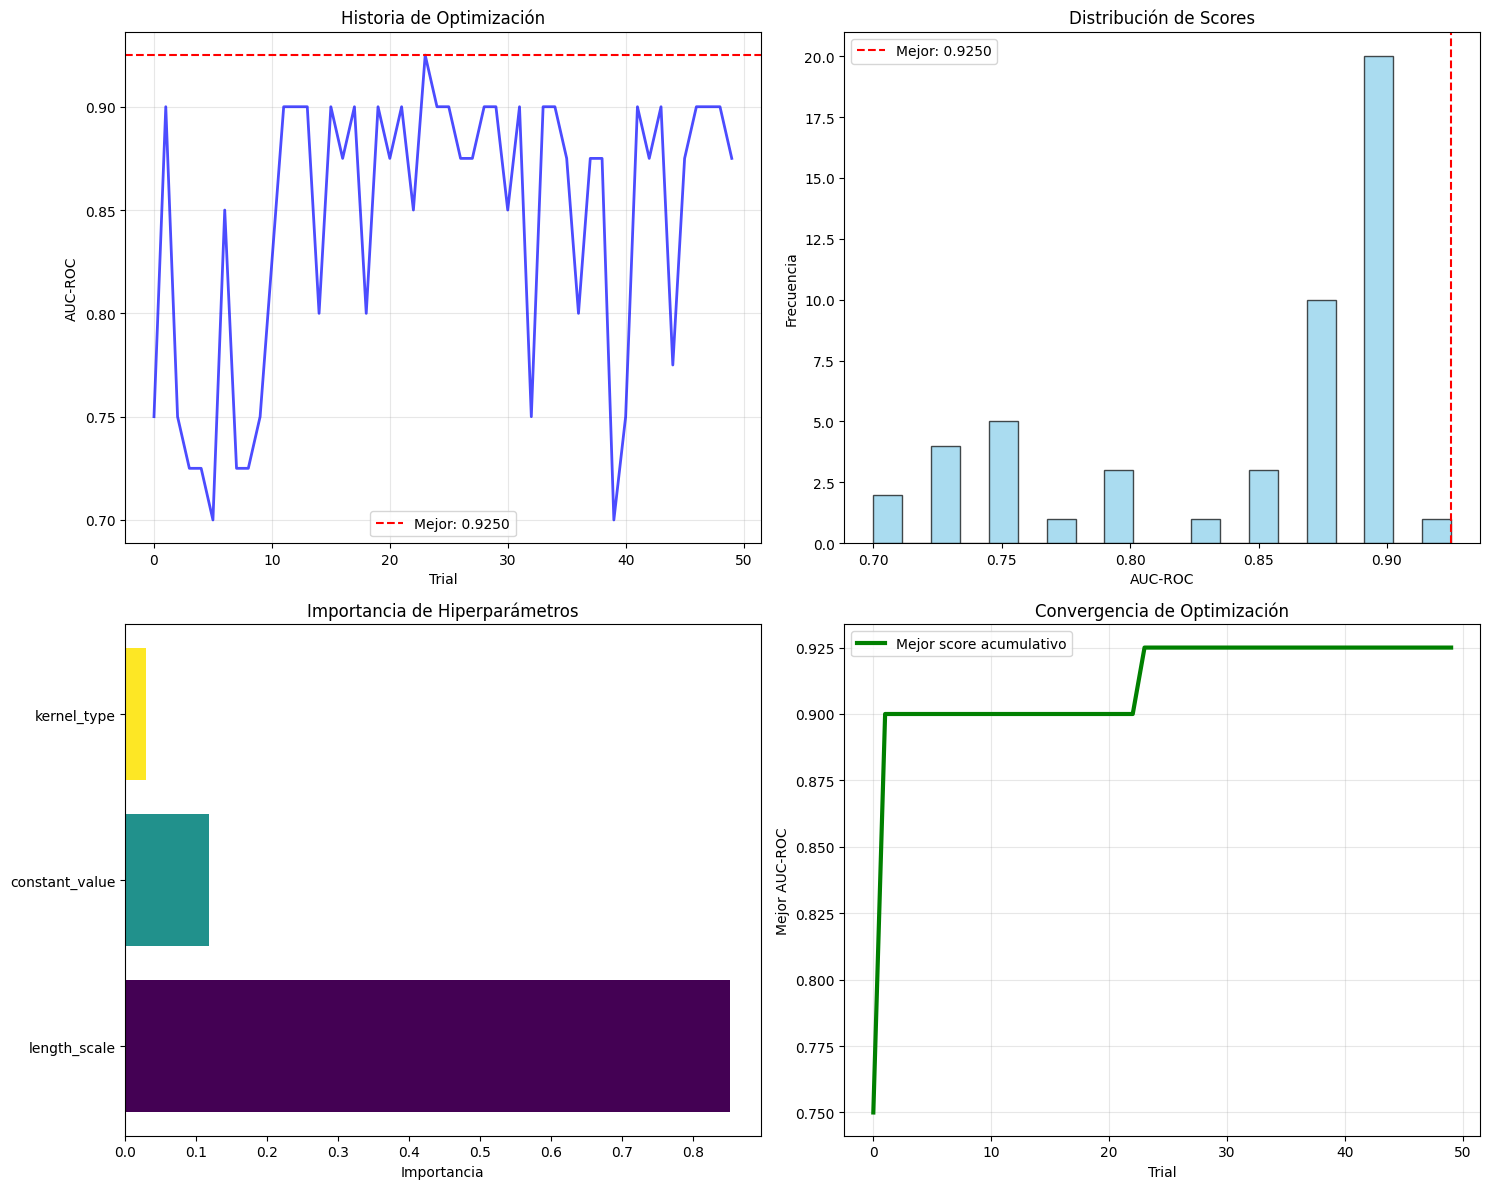


 2: ENTRENAMIENTO DEL MODELO

MODELO FINAL ENTRENADO
Kernel optimizado: 9.85**2 * Matern(length_scale=6.98, nu=2.5)

 3: EVALUACIÓN DEL MODELO

EVALUACIÓN DEL MODELO
Usando Leave-One-Out cross-validation...

Matriz de Confusión:
[[18  2]
 [ 4 16]]

Reporte de Clasificación:
              precision    recall  f1-score   support

     Control       0.82      0.90      0.86        20
        TDAH       0.89      0.80      0.84        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40


AUC-ROC: 0.9275

ANÁLISIS DE INCERTIDUMBRE
Incertidumbre promedio: 0.283
Incertidumbre mediana: 0.321
Incertidumbre máxima: 0.495
Incertidumbre mínima: 0.064

Predicciones con mayor incertidumbre:
1. Predicho: TDAH, Real: Control Fail
   Prob Control: 0.438, Prob TDAH: 0.562
   Incertidumbre: 0.438
2. Predicho: Control, Real: Control correct
   Prob Control: 0.553, Prob TDAH: 0.447
   Incertid

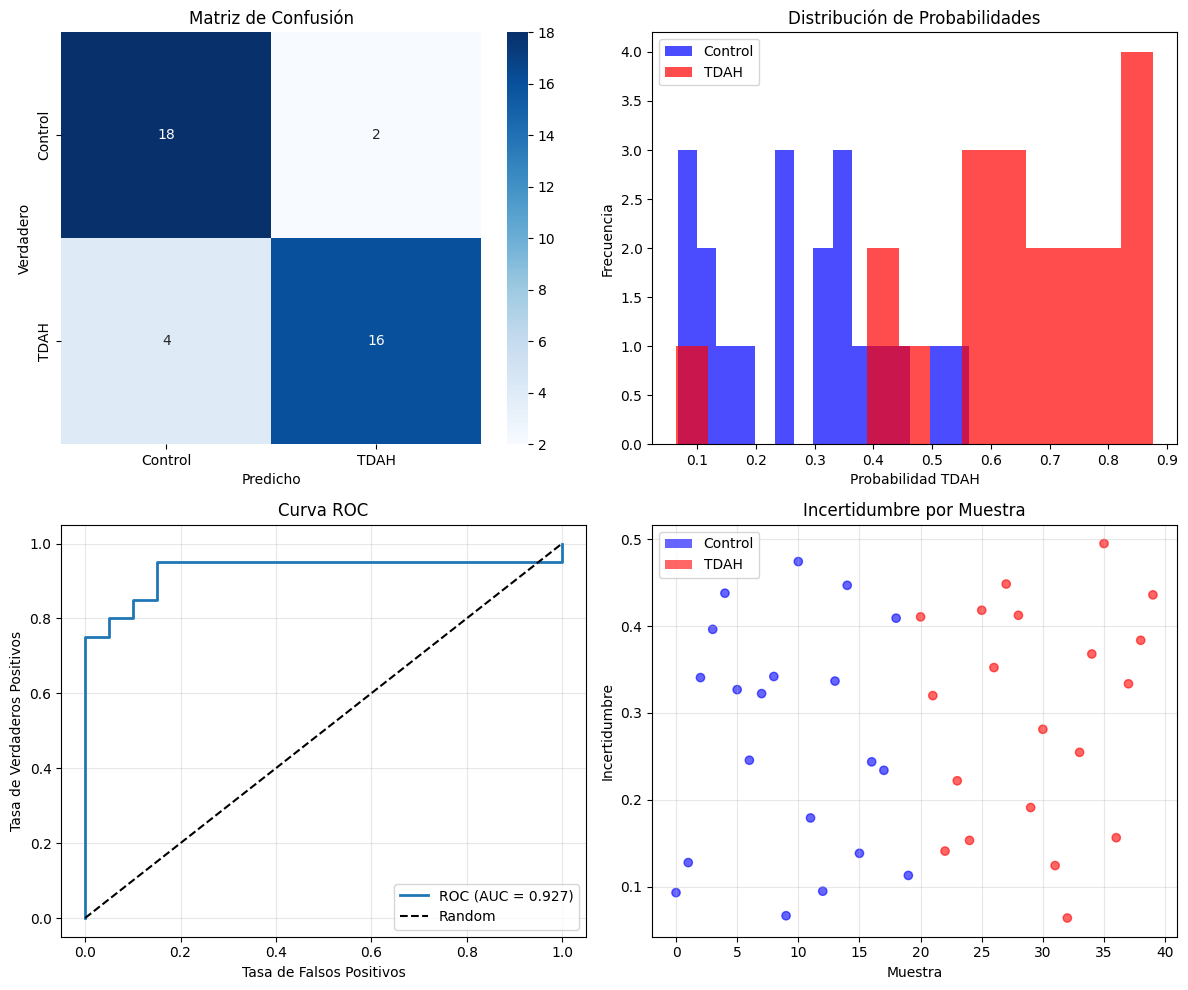

In [ ]:
classifier, results = main()

###Analisis de resultados:

* **Gráfico de historial de optimización (AUC-ROC por trial):**

    Muestra una alta variabilidad en los primeros intentos, seguida de una región estable con AUC altos. Pero a partir del trial 20, el modelo alcanza valores superiores a 90%.

* **Gráfico de distribución de Scores:**

  La mayor parte de los trial se concentra en la región [0.85-0.925] de AUC.

* **Gráfico de importancia de hiperparametro:**

  El parametro *length_scale* del kernel Matérn domina la importancia. Así mismo, los parametros de tipo de kernel y *constant_value* no contribuye mucho.

* **Gráfico de convergencia de optimización:**

  Se alcanza rapidamente un AUC-ROC de 0.9 al segundo trial, y despues mejora a 0.925 cerca del trial 23 y se mantiene constante.

* **Gráfico de matriz de confusión:**

  - En control hubo 18/20 bien clasificados (2 falsos positivos)
  - TDAH hubo 16/20 bien clasificados (4 falsos positivos)

* **Gráfico de distribución de probabilidades**:

  Las probabilidades de clase están bien separadas entre los grupos, aunque hay casos de superposición leve en la zona [0.4–0.6], lo cual genera incertidumbre.

* **Gráfico de curva ROC **:

  AUC = 0.927, curva muy por encima del azar, mostrando una alta tasa de verdaderos positivos con baja Tasa de Falsos Positivos. Indicando que el modelo ofrece un desempeño discriminativo bueno.

* **Gráfico de incertidumbre por muestra:**

  Variabilidad en la incertidumbre, con valores desde 0.06 hasta 0.49, donde las muestras con mayor incertidumbre son las que se predicen erróneamente (predicciones 50/50). Esta información puede mostrar lo dificil que puede ser la clasificación entre pacientes.


### Conclusión

La implementación de un clasificador basado en Procesos Gaussianos para distinguir entre sujetos con TDAH y controles a partir de parámetros HMM derivados de señales EEG ha demostrado ser efectiva. Se alcanzó un AUC-ROC de 0.9275 y una exactitud del 85% bajo validación Leave-One-Out, evidenciando un buen equilibrio entre sensibilidad y especificidad. El mejor desempeño se logró utilizando un kernel Matérn 2.5, adecuado para capturar patrones suaves pero no excesivamente rígidos. Aunque, se identificaron predicciones con alta incertidumbre cerca de la frontera entre clases, lo que resalta la necesidad de incorporar mayor tratamiento a los datos ademas de comparar con modelos alternativos. Este enfoque ofrece la ventaja de estimar incertidumbre, una propiedad valiosa en contextos clínicos.

---

NOTA: Inicialmente se habia propuesto un clasificador que incorpora distancias en RKHS entre HMM, pero este enfoque no arrojo los resultados esperados. Se sigue investigando al respecto.

